# Summary of mapping data

In this notebook we summarize and filter the barcode-promoter mapping and compile everything into a table.

In [1]:
from glob import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import phd_pkg

phd_pkg.viz.matplotlib_style()

Barcodes need to me unique to a promoter variant. So here we filter out any barcodes that map to more than one promoter variant and only keep unique barcodes.

In [2]:
df_map = pd.read_csv("../data/mapping/mapped_barcodes_filtered.csv")

## DicA binding site in dicC promoter

The promoter for dicC contains a binding site for DicA, which we can find by looking at the mutation rate across all sequenced promoter variants for the dicC promoter.


In [3]:
mut_mat = np.zeros([4, 160])
let_dict = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

for _, row in df_map[df_map['name'] == 'dicCp'].iterrows():
    for i, l in enumerate(row['promoter']):
        mut_mat[let_dict[l], i] += row['count']

In [4]:
mut_mat /= np.sum(mut_mat, axis=0)

In [5]:
mut_rate  = 1-np.max(mut_mat, axis=0)

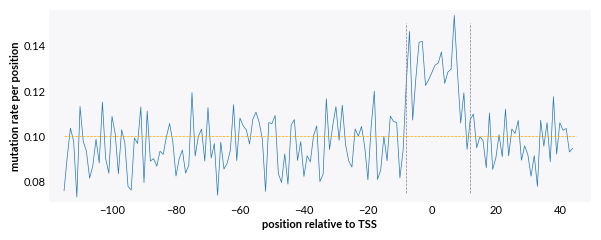

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.5))
ax.plot(np.arange(-115, 45), mut_rate)
ax.plot([-115, 45], [0.1, 0.1], ls='--', color='orange')
ax.vlines([-8, 12], ymin=0.075, ymax=0.15, ls='--', color='gray')

ax.set_xlabel('position relative to TSS')
ax.set_ylabel('mutation rate per position')

fig.savefig('../figures/dicC_mutation_rate.pdf')

## Filter out promotes with only one barcode

In [7]:
min_rows = 1

df_filtered = df_map.groupby("promoter").filter(
    lambda g: len(g) > min_rows
)
df_filtered['promoter'].nunique()

175257

In [8]:
min_rows = 1

df_low = df_map.groupby("promoter").filter(
    lambda g: len(g) == min_rows
)
df_low['promoter'].nunique()

201398

In [9]:
df_unique = df_filtered.groupby('name')['promoter'].nunique().sort_values(ascending=True)
df_unique_low = df_low.groupby('name')['promoter'].nunique().sort_values(ascending=True)

In [10]:
tss_names = {
    "TSS_1414_storz_regulondb": 'yahM',
    'TSS_18061_regulondb': 'yjjJ',
    'TSS_4654_wanner_regulondb': 'ymfJ',
    'TSS_4655_regulondb': 'ymfJ_2',
    'TSS_6311_regulondb': 'dicA',
}


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_31999/2292310714.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=4.5)


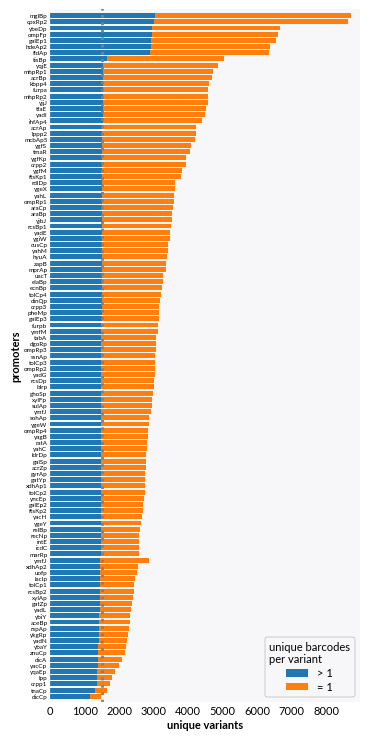

In [11]:
fig, ax = plt.subplots(figsize=(4, 9))

labels = [tss_names[x] if x in tss_names.keys() else x for x in df_unique.index]
labels = [x.split('_')[0] for x in labels]

ax.barh(labels, df_unique.values, label='> 1')
ax.barh(labels, df_unique_low.values, left=df_unique.values, label='= 1')


ax.set_yticklabels(labels, fontsize=4.5)
ax.plot([1500, 1500], [-1, 112], ls='dotted', lw=2, color='gray')
ax.set_ylim(-1, 111)
ax.set_xlabel('unique variants', fontsize=8)
ax.set_ylabel('promoters', fontsize=8)
ax.legend(title='unique barcodes\nper variant', title_fontsize=8, fontsize=8)
fig.savefig('../figures/barcodes_per_promoter_variant.pdf')

Compare to twist

In [14]:
df_twist = pd.read_csv('../data/twist_order_sequences.csv')
pool = [x[26:186] for x in df_twist['sequence']]

In [ ]:
print(len(np.intersect1d(pool, df_map['promoter'].unique())) / len(df_twist))
print(len(np.intersect1d(pool, df_map['promoter'].unique())))

0.9702719195606291
173309


In [51]:
min_rows = 1

df_filtered = df_map.groupby("promoter").filter(
    lambda g: len(g) > min_rows
)
df_filtered['promoter'].nunique()

175257

In [52]:
print(len(np.intersect1d(pool, df_filtered['promoter'].unique())) / len(df_twist))
print(len(np.intersect1d(pool, df_filtered['promoter'].unique())))

0.9652836484360566
172418


In [47]:
np.sum(df_map.groupby('promoter').size().values == 1) / len(df_map.groupby('promoter'))

np.float64(0.5347015173036332)

In [ ]:
np.setdiff1d(df_low['promoter'].unique(), pool)

(array([2.78049e+05, 7.45730e+04, 1.95960e+04, 3.47700e+03, 7.49000e+02,
        1.51000e+02, 4.80000e+01, 9.00000e+00, 1.00000e+00, 2.00000e+00]),
 array([  1. ,  23.5,  46. ,  68.5,  91. , 113.5, 136. , 158.5, 181. ,
        203.5, 226. ]),
 <BarContainer object of 10 artists>)

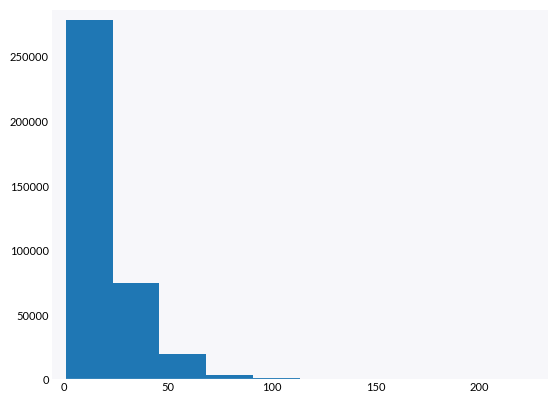

In [43]:
plt.hist(df_map.groupby('promoter').size())

In [49]:
df_map['promoter'].unique()

array(['AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTGAGTAGTCAGATGATAACGCCCTGACGATAAATTTGCAGTTTCATGATTTCCCTGTATTTTATGACTGGATGGATTACCCTGATCAGCCTGTTAAGTTTGTTTTTCACATACTTG',
       'AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTGAGTAGTCAGATGATAACGCCCTGACGATAAATTTGCAGTTTCATGATTTCCCTGTATTTTATGACTGGATGGATTACCCTGATCAGCCTGTTAAGTTTGTTTTTCACATATTTG',
       'AAAGACGCCAAACTCATTGATCTCACGGCTGCCGTACGGGCCTGTGAGAGGTCAGACGATAACGCACTCACCATAAATGTGCAGTTTTATATTCTCCCTGGTTTTTATGACTGGATGCATTACCCTGATCACCCGGTTAAGTTTGTTTTTCACAGACTTC',
       ...,
       'TTTTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAGCGTTTTGTTATGGAGCATAATGTGACCAATAAGCGTAATGCTTATGAGAAGTGTGATATTATAACCCTTCTTGAATACTGCAAGACTAAAATTGACATGACACGTCTGGTTCCC',
       'TTTTTGCACCTCCCCTCAGAGGGGCGGATAATGCTGCGAAAAGAACCGTTTTTTTATGTAACATAATGAGCCCAACACCCGTAATGAATAAGAGAAGTATGAGATTATAACAGTTCATGACTACTGCAAGACTAAAATTAACATCACAAGTCTGGTTTCC',
       'TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAGCATTTTTGTATGTAAAATTATGCGACCTATAATCGTAATGAATATGCGAAGTGTGATATTATGACATTACATGACTACT

In [50]:
len(df_twist)

178619